# PART A – **ANN FOR REGRESSION**

# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Name : Adhiraj S C")
print("Roll No : 24BAD003")

Name : Adhiraj S C
Roll No : 24BAD003


# Load  dataset

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()

In [ ]:
# Features (Input)
X = housing.data

# Target (Output)
y = housing.target

# Convert to a Pandas DataFrame
df = pd.DataFrame(X, columns=housing.feature_names)

# Add the target column
df["HouseValue"] = y

# Display the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Split the data into train and test sets.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling the features

In [ ]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test = scaler.transform(X_test)

# Build ANN model

In [ ]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile the model

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Training

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8973 - mae: 0.6549 - val_loss: 0.4809 - val_mae: 0.4948
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4316 - mae: 0.4621 - val_loss: 0.4219 - val_mae: 0.4561
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3775 - mae: 0.4381 - val_loss: 0.4044 - val_mae: 0.4553
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3578 - mae: 0.4249 - val_loss: 0.4296 - val_mae: 0.4510
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3530 - mae: 0.4190 - val_loss: 0.4152 - val_mae: 0.4434
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3447 - mae: 0.4113 - val_loss: 0.4243 - val_mae: 0.4722
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3454 - mae: 0.4093 - val_loss: 0.3582 - val_mae: 0.4122
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3186 - mae: 0.3965 - val_loss: 0.3372 - val_mae: 0.4030
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

# Prediction


In [ ]:
# Predict house prices for the test data
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print('Actual prices: ')
y_pred=y_pred.flatten()
print(y_test[:5])
print('\npredicted prices: ')
print(y_pred[:5])

Actual prices: 
[0.477   0.458   5.00001 2.186   2.78   ]

predicted prices: 
[0.45792896 1.2490518  4.634453   2.3518279  2.844663  ]


# Visualizations

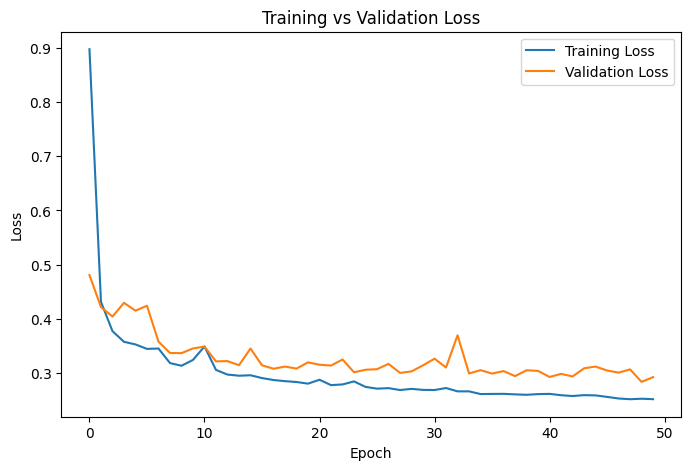

In [ ]:
# Plot Training Loss vs Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Evaluation


In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print("MSE:", round(mse,2))
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

MSE: 0.28
MAE: 0.35
RMSE: 0.52
